In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [2]:
img = cv2.imread(r"flower.jpeg", 0)
equ = cv2.equalizeHist(img)
equ

array([[229, 226, 221, ..., 228, 228, 228],
       [233, 230, 226, ..., 233, 233, 233],
       [237, 235, 232, ..., 239, 239, 239],
       ...,
       [198, 201, 208, ..., 191, 191, 191],
       [198, 201, 208, ..., 193, 193, 193],
       [198, 201, 208, ..., 190, 190, 190]], shape=(444, 691), dtype=uint8)

In [3]:
hist1 = cv2.calcHist([img], [0], None, [256], [0, 256])
hist2 = cv2.calcHist([equ], [0], None, [256], [0, 256])

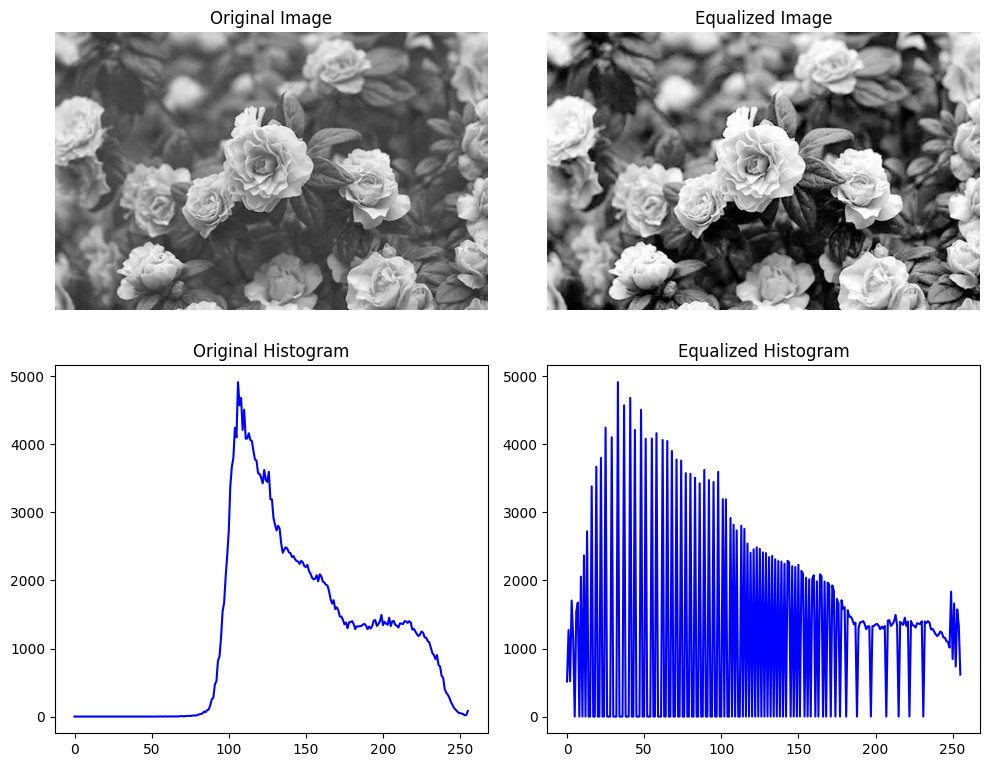

In [10]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

axs[0, 0].imshow(img, cmap='gray')
axs[0, 0].set(title='Original Image')
axs[0, 0].axis('off')  

axs[0, 1].imshow(equ, cmap='gray')
axs[0, 1].set(title='Equalized Image')
axs[0, 1].axis('off')  

axs[1, 0].plot(hist1, 'b')
axs[1, 0].set_title('Original Histogram')

axs[1, 1].plot(hist2, 'b')
axs[1, 1].set_title('Equalized Histogram')

plt.tight_layout()
plt.show()

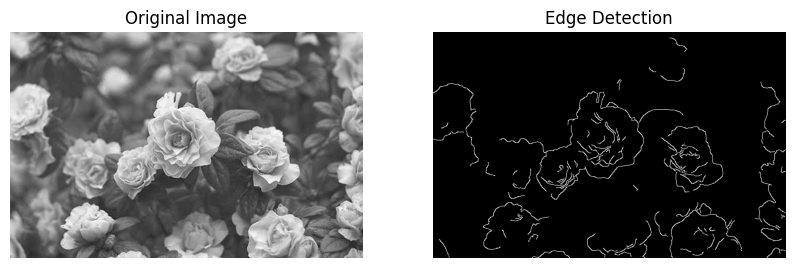

In [13]:
blurred = cv2.GaussianBlur(img, (5, 5), 0)
edges = cv2.Canny(blurred, 100, 200)

fig, axs = plt.subplots(1, 2, figsize=(10, 8))
axs[0].imshow(img, cmap='gray')
axs[0].set(title='Original Image', label = False)
axs[1].imshow(edges, cmap='gray')
axs[1].set(title='Edge Detection', label = False)
axs[0].axis('off')
axs[1].axis('off')
plt.show()

In [6]:
from PIL import Image
from torchvision import transforms

img_bgr = cv2.imread(r"flower.jpeg")
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
pil_img = Image.fromarray(img_rgb) 

augment = transforms.Compose([
    transforms.RandomRotation(40),                     
    transforms.RandomResizedCrop(
        size=pil_img.size[::-1],                        
        scale=(0.8, 1.0)                                 
    ),
    transforms.RandomHorizontalFlip(p=0.5),              
])

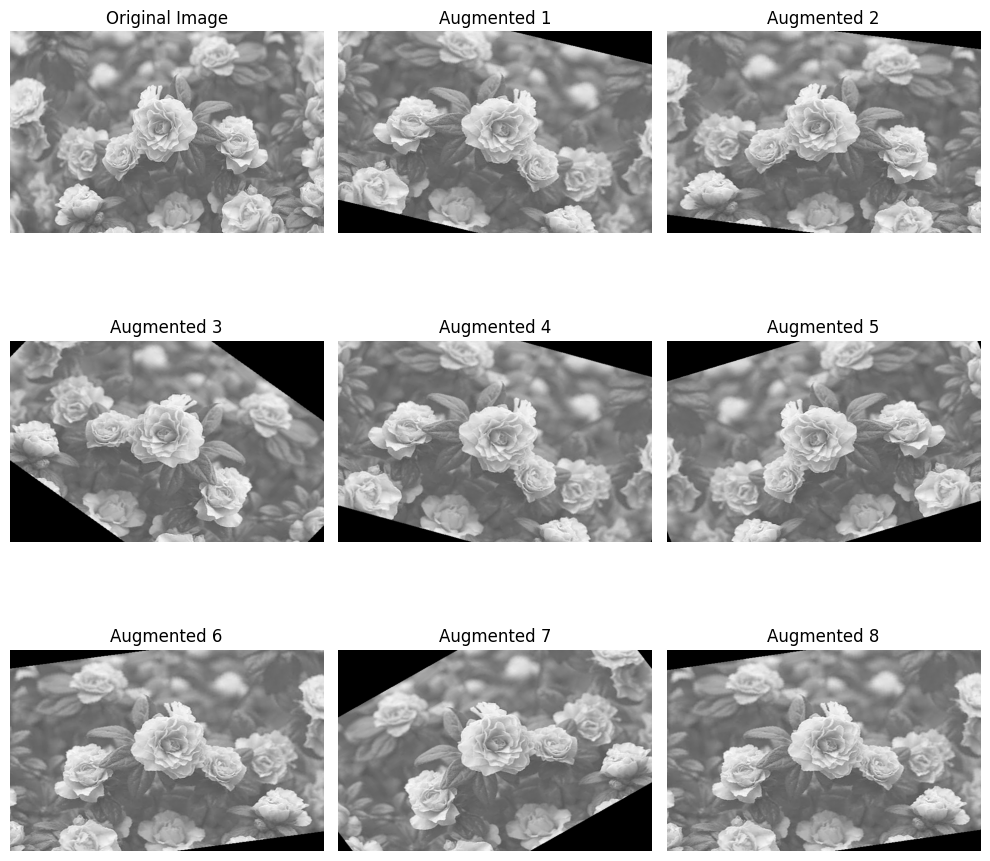

In [ ]:
fig, axs = plt.subplots(3, 3, figsize=(10, 10))
axs = axs.flatten()

axs[0].imshow(pil_img)
axs[0].set(title="Original Image", label = False)
axs[0].axis('off')

for i in range(8):
    axs[i+1].imshow(augment(pil_img))
    axs[i+1].set(title=f"Augmented {i+1}", label = False)
    axs[i+1].axis('off')

plt.tight_layout()
plt.savefig("Augmented_Image.png", bbox_inches='tight')
plt.show()

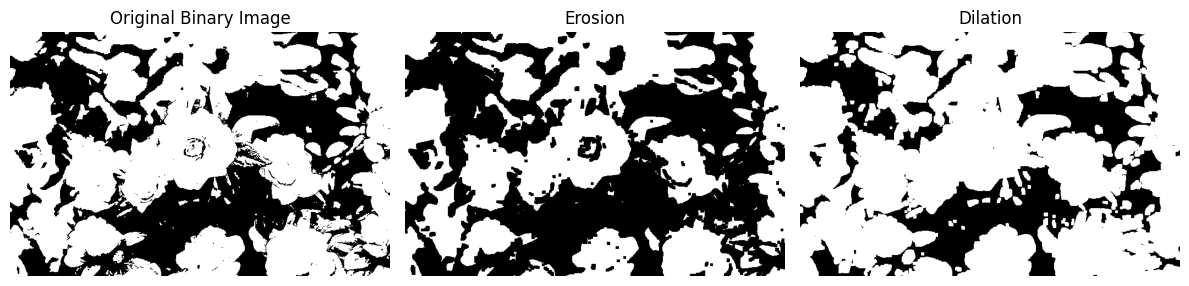

In [ ]:
_, binary_img = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
kernel = np.ones((5, 5), np.uint8)
erosion = cv2.erode(binary_img, kernel, iterations=1)
dilation = cv2.dilate(binary_img, kernel, iterations=1)

fig, axs = plt.subplots(1, 3, figsize=(12, 8))
titles = ["Original Binary Image", "Erosion", "Dilation"]
images = [binary_img, erosion, dilation]
for ax, im, t in zip(axs, images, titles):
    ax.imshow(im, cmap='gray')
    ax.set(title=t, label = False)
    ax.axis('off')

plt.tight_layout()
plt.savefig("Morphological_Operation.png", bbox_inches='tight')
plt.show()



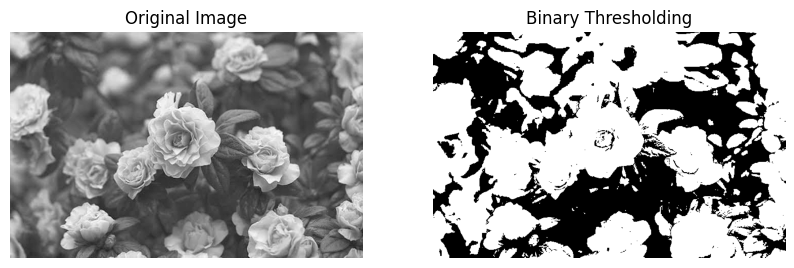

In [19]:
_, threshold = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

fig, axs = plt.subplots(1, 2, figsize=(10, 8))
axs[0].imshow(img, cmap='gray')
axs[0].set(title='Original Image', label = False)
axs[0].axis('off')
axs[1].imshow(threshold, cmap='gray')
axs[1].set(title='Binary Thresholding', label = False)
axs[1].axis('off')

plt.savefig("Thresholding_Result.png", bbox_inches='tight')
plt.show()